In [2]:
# ===============================
# 1. Montar Google Drive y cargar dataset
# ===============================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np

# Cambia esta ruta por la de tu archivo en Drive
file_path = "poker-hand-all-no-label.csv"
data = pd.read_csv(file_path)

print("Shape del dataset:", data.shape)
print(data.head())

# Convertimos a array numpy
X = data.values

Shape del dataset: (1025010, 10)
   S1  C1  S2  C2  S3  C3  S4  C4  S5  C5
0   1  10   1  11   1  13   1  12   1   1
1   2  11   2  13   2  10   2  12   2   1
2   3  12   3  11   3  13   3  10   3   1
3   4  10   4  11   4   1   4  13   4  12
4   4   1   4  13   4  12   4  11   4  10


C:\Users\saygu\AppData\Local\Temp\ipykernel_13308\705027421.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=y, s=1, cmap="tab10")


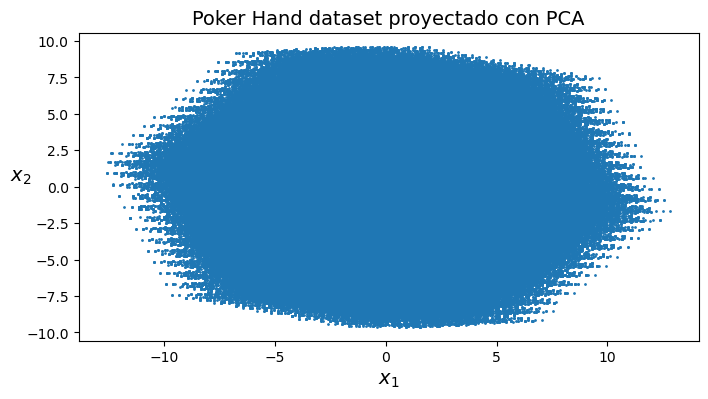

In [6]:
# ===============================
# 2. Visualización inicial con PCA a 2D
# ===============================
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

def plot_clusters(X, y=None, title=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1, cmap="tab10")
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)
    if title:
        plt.title(title, fontsize=14)

plt.figure(figsize=(8,4))
plot_clusters(X_2d, title="Poker Hand dataset proyectado con PCA")
plt.show()

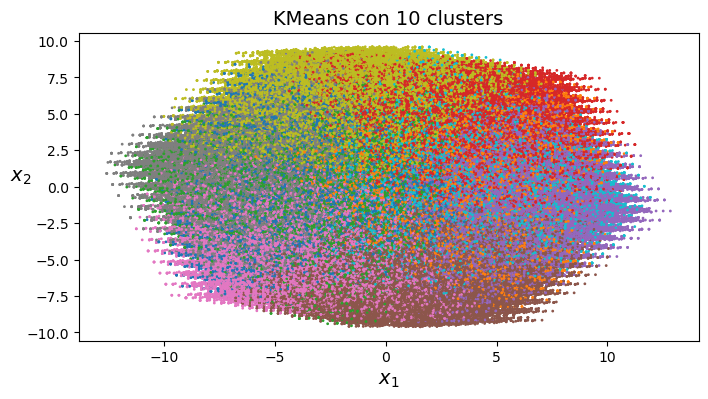

In [7]:
# ===============================
# 3. Aplicar KMeans
# ===============================
from sklearn.cluster import KMeans
import random

k = random.randint(1, 10)

#k = 10  # número de clusters arbitrario, puedes ajustar
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

plt.figure(figsize=(8,4))
plot_clusters(X_2d, y_pred, title=f"KMeans con {k} clusters")
plt.show()

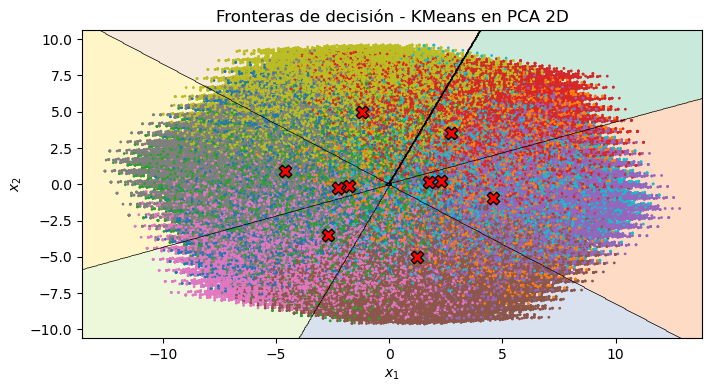

In [8]:
# ===============================
# 4. Visualizar fronteras de decisión en 2D (PCA space)
# ===============================
def plot_decision_boundaries(clusterer, X, resolution=500, show_centroids=True):
    # X es en 2D (tras PCA)
    mins = X.min(axis=0) - 1
    maxs = X.max(axis=0) + 1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap="Pastel2", alpha=0.7)
    plt.contour(xx, yy, Z, linewidths=0.5, colors='k')
    plt.scatter(X[:,0], X[:,1], c=clusterer.labels_, s=1, cmap="tab10")

    if show_centroids:
        centers_2d = pca.transform(clusterer.cluster_centers_)
        plt.scatter(centers_2d[:,0], centers_2d[:,1],
                    c="red", s=80, marker="X", edgecolors="k")

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")

plt.figure(figsize=(8,4))
plot_decision_boundaries(kmeans, X_2d)
plt.title("Fronteras de decisión - KMeans en PCA 2D")
plt.show()

C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NU

Score final del mejor modelo: -39851195.18465188


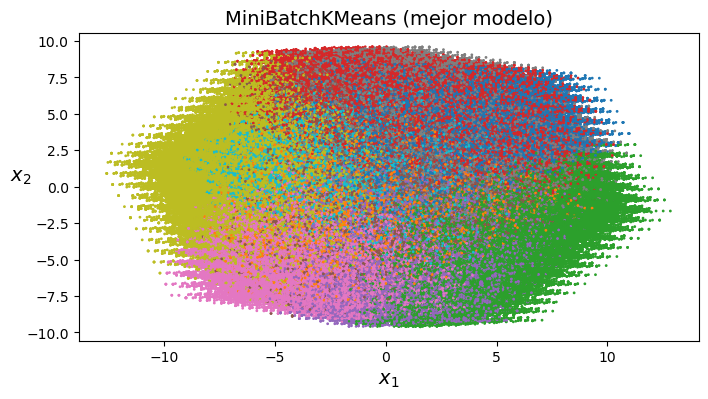

In [9]:
# ===============================
# 5. MiniBatch KMeans (similar al ejemplo original)
# ===============================
from sklearn.cluster import MiniBatchKMeans

k = 10
n_init = 10
n_iterations = 50
batch_size = 256
init_size = 1000
evaluate_on_last_n_iters = 5

def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size, random_state=init)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

print("Score final del mejor modelo:", best_kmeans.score(X))

# Visualización final con PCA
plt.figure(figsize=(8,4))
plot_clusters(X_2d, best_kmeans.predict(X), title="MiniBatchKMeans (mejor modelo)")
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)